# Dictionary Handling

```
*** Settings ***
Library    Collections

*** Test Cases ***

Working with dictionary
    &{data}=    Create Dictionary    name=rahulshetty    course=robotframework    website=rahulshettyacademy.com
    Log    ${data}
    Dictionary Should Contain Key    ${data}    name
    Log    ${data}[name]
    ${url}=    Get From Dictionary    ${data}    website
    Log    ${url}
```

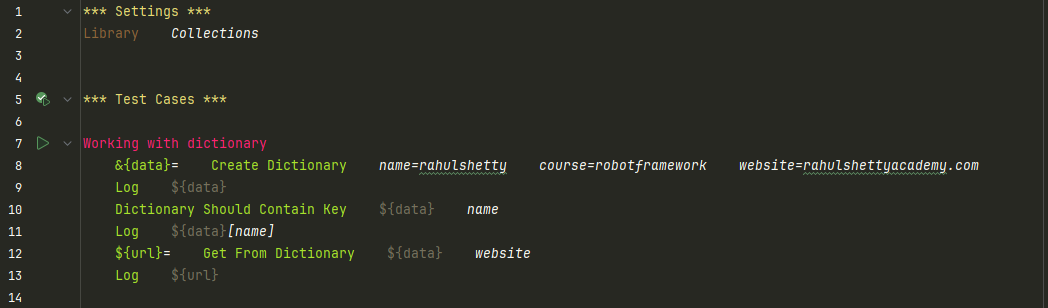

# API testing using Request Library

Install Python Request Library: **`pip install robotframework-requests`**

```
*** Settings ***
Library    Collections
Library    RequestsLibrary

*** Variables ***
${base_url}    https://rahulshettyacademy.com
${book_id}
${book_name}    RobotFramework

*** Test Cases ***

Add Book in to Library
    &{req_body}=    Create Dictionary    name=${book_name}    isbn=58698694    aisle=8787664    author=rahulshetty
    ${response}=    POST    ${base_url}/Library/Addbook.php    json=${req_body}
    Log    ${response.json()}
    Dictionary Should Contain Key    ${response.json()}    ID
    ${book_id}=    Get From Dictionary   ${response.json()}    ID
    Set Global Variable    ${book_id}
    Log    ${book_id}
    Should Be Equal As Strings    successfully added    ${response.json()}[Msg]
    Status Should Be    200    ${response}

Get the book details from Library
     ${get_response}=    GET    ${base_url}/Library/GetBook.php    params=ID=${book_id}    expected_status=200
     Log    ${get_response.json()}
     Should Be Equal As Strings    ${book_name}    ${get_response.json()}[0][book_name]


Delete the book from Library
    &{req_body}=    Create Dictionary    ID=${book_id}
    ${delete_response}=    POST    ${base_url}/Library/DeleteBook.php    json=${req_body}    expected_status=200
    Log    ${delete_response.json()}
    Should Be Equal As Strings    book is successfully deleted    ${delete_response.json()}[msg]
```

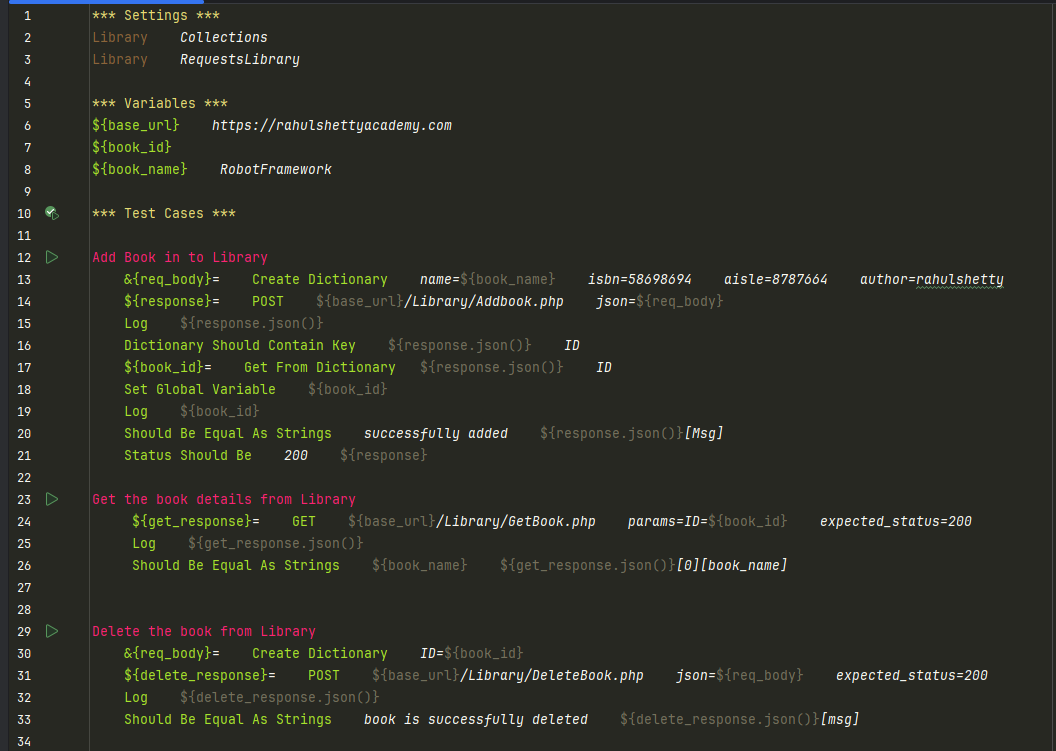